# Decision Tree

Input: `cleaned_startup_data.csv` (01 notebook se).

Steps: split -> default model -> hyperparameter tuning -> results

Decision Tree ko scaling ki zaroorat nahi hoti.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

from sklearn.tree import DecisionTreeClassifier, plot_tree

## 1. Data load

In [2]:
import os
if not os.path.exists('/content/cleaned_startup_data.csv'):
    from google.colab import files
    files.upload()

df = pd.read_csv('/content/cleaned_startup_data.csv')
print(df.shape)
df.head()

(11787, 7)


,funding_rounds,target,funding_missing,founded_at_year,first_funding_at_year,last_funding_at_year,log_funding
0,1,1,0,2012.0,2015.0,2015.0,15.424949
1,1,1,0,2009.0,2009.0,2009.0,13.122365
2,2,1,0,2010.0,2010.0,2011.0,14.745705
3,2,1,0,2011.0,2011.0,2011.0,14.038655
4,1,1,0,2000.0,2010.0,2010.0,17.370859


## 2. Train test split

In [3]:
X = df.drop(columns=['target'])
y = df['target']

# 80% train, 20% test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape)
print('Test :', X_test.shape)


Train: (9429, 6)
Test : (2358, 6)


## 3. Default Decision Tree

Koi limit nahi lagayi, to tree jab tak possible hai badhta rahega.

In [4]:
def get_scores(y_true, y_pred, y_prob):
    scores = {}
    scores['Accuracy'] = accuracy_score(y_true, y_pred)
    scores['Precision'] = precision_score(y_true, y_pred)
    scores['Recall'] = recall_score(y_true, y_pred)
    scores['F1'] = f1_score(y_true, y_pred)
    scores['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    return scores

In [5]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

pred_default = dt_default.predict(X_test)
prob_default = dt_default.predict_proba(X_test)[:, 1]

scores_default = get_scores(y_test, pred_default, prob_default)
for name, value in scores_default.items():
    print(name, ':', round(value, 4))

print()
print('Train accuracy:', round(dt_default.score(X_train, y_train), 4))
print('Test accuracy :', round(dt_default.score(X_test, y_test), 4))
print('Tree depth    :', dt_default.get_depth())

Accuracy : 0.6531
Precision : 0.646
Recall : 0.582
F1 : 0.6123
ROC-AUC : 0.6433

Train accuracy: 0.9325
Test accuracy : 0.6531
Tree depth    : 34


Train accuracy test se bahut zyada hai, matlab tree ne training data ratt liya (overfitting). Tuning se ye theek hoga.

## 4. Hyperparameter tuning

- `max_depth` : tree ki maximum depth
- `min_samples_split` : node split karne ke liye kam se kam kitne samples
- `min_samples_leaf` : leaf me kam se kam kitne samples
- `criterion` : gini ya entropy

In [6]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 5, 20, 50],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best CV ROC-AUC:', round(grid.best_score_, 4))

Best parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 50, 'min_samples_split': 2}
Best CV ROC-AUC: 0.7729


In [7]:
dt_tuned = grid.best_estimator_

pred_tuned = dt_tuned.predict(X_test)
prob_tuned = dt_tuned.predict_proba(X_test)[:, 1]

scores_tuned = get_scores(y_test, pred_tuned, prob_tuned)
for name, value in scores_tuned.items():
    print(name, ':', round(value, 4))

print()
print('Train accuracy:', round(dt_tuned.score(X_train, y_train), 4))
print('Test accuracy :', round(dt_tuned.score(X_test, y_test), 4))
print('Tree depth    :', dt_tuned.get_depth())

Accuracy : 0.7129
Precision : 0.7084
Recall : 0.6631
F1 : 0.685
ROC-AUC : 0.782

Train accuracy: 0.7171
Test accuracy : 0.7129
Tree depth    : 7


## 5. Comparison: default vs tuned

In [8]:
results = pd.DataFrame({'Default': scores_default, 'Tuned': scores_tuned}).T
results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Default,0.6531,0.6460,0.5820,0.6123,0.6433
Tuned,0.7129,0.7084,0.6631,0.6850,0.7820


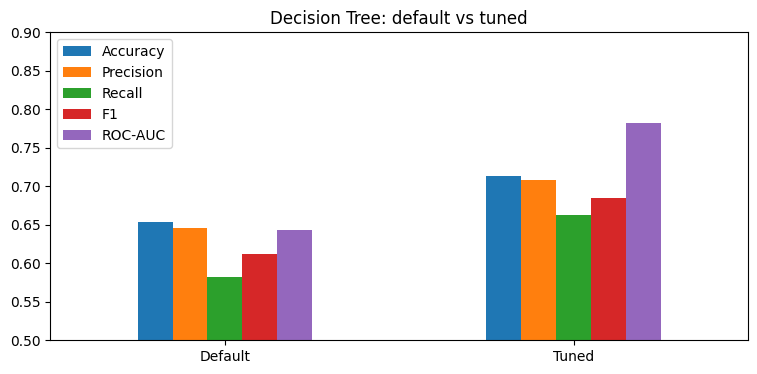

In [9]:
results.plot(kind='bar', figsize=(9, 4), ylim=(0.5, 0.9))
plt.title('Decision Tree: default vs tuned')
plt.xticks(rotation=0)
plt.show()

## 6. Confusion matrix

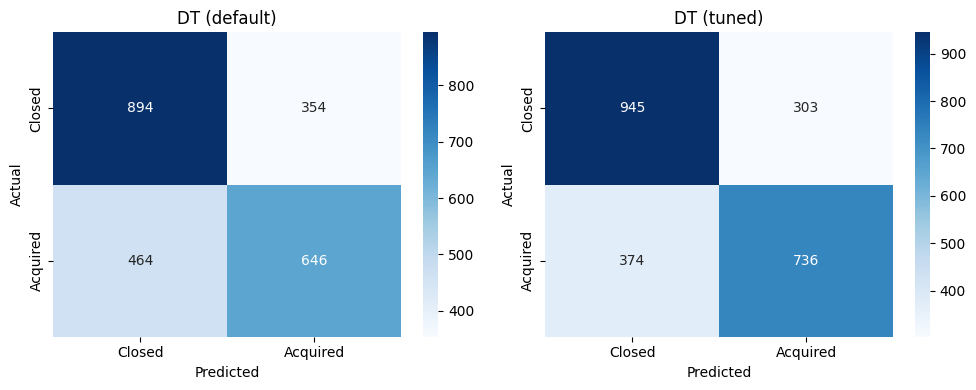

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, pred_default), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
axes[0].set_title('DT (default)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, pred_tuned), annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
axes[1].set_title('DT (tuned)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [11]:
print(classification_report(y_test, pred_tuned, target_names=['Closed', 'Acquired']))

              precision    recall  f1-score   support

      Closed       0.72      0.76      0.74      1248
    Acquired       0.71      0.66      0.68      1110

    accuracy                           0.71      2358
   macro avg       0.71      0.71      0.71      2358
weighted avg       0.71      0.71      0.71      2358



## 7. ROC curve

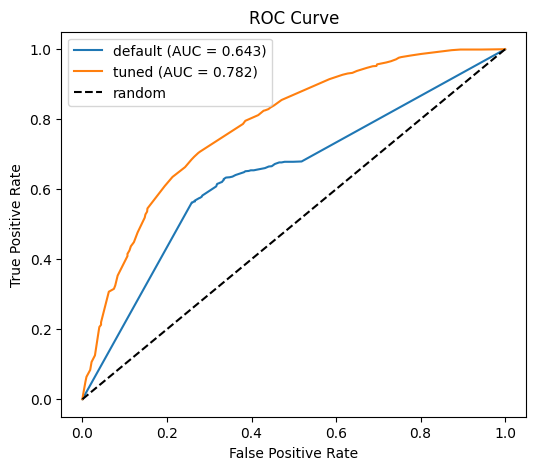

In [12]:
fpr1, tpr1, _ = roc_curve(y_test, prob_default)
fpr2, tpr2, _ = roc_curve(y_test, prob_tuned)

plt.figure(figsize=(6, 5))
plt.plot(fpr1, tpr1, label='default (AUC = %.3f)' % roc_auc_score(y_test, prob_default))
plt.plot(fpr2, tpr2, label='tuned (AUC = %.3f)' % roc_auc_score(y_test, prob_tuned))
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 8. Feature importance

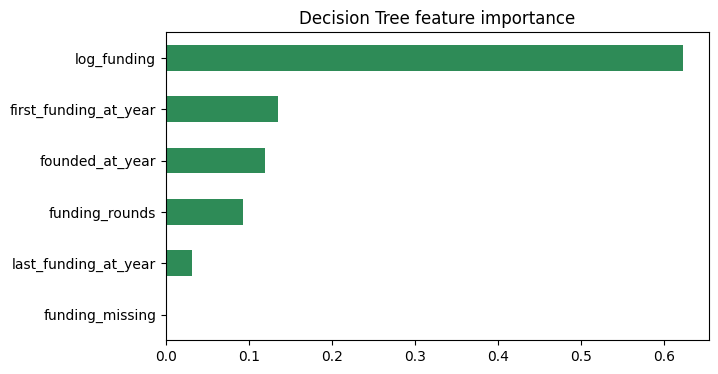

In [13]:
imp = pd.Series(dt_tuned.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', figsize=(7, 4), color='seagreen')
plt.title('Decision Tree feature importance')
plt.show()

## 9. Tree ka diagram (upar ke 3 levels)

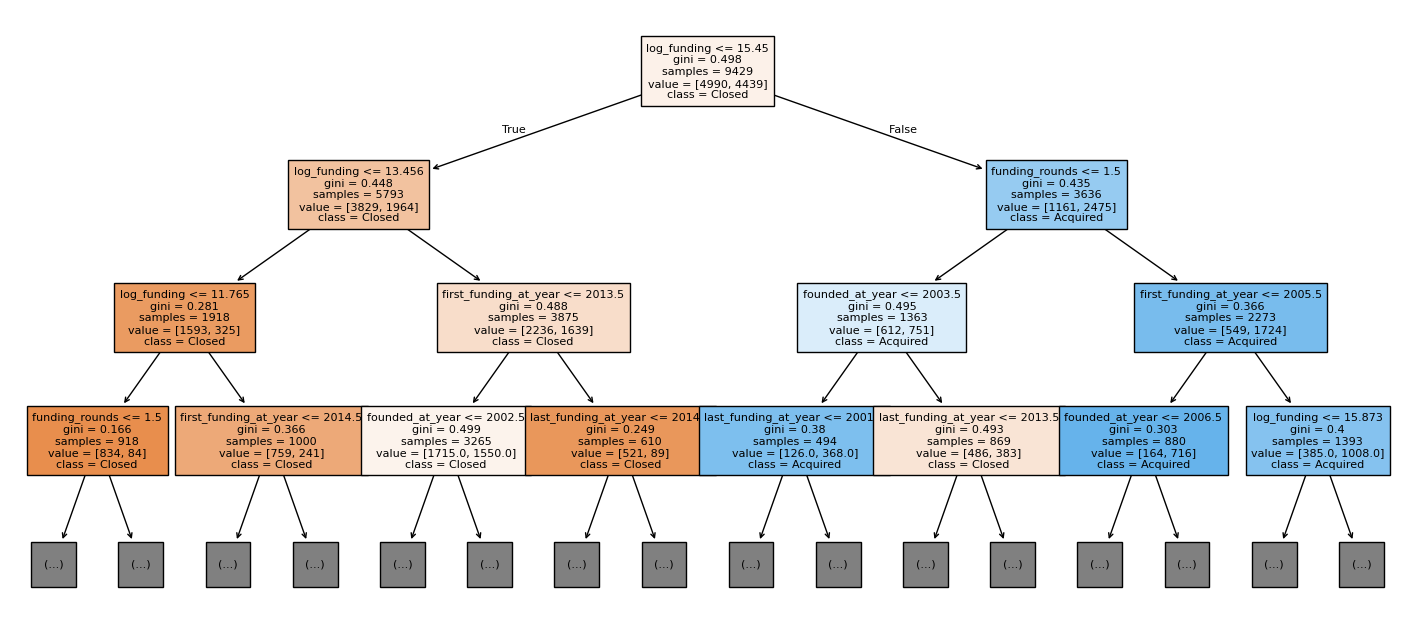

In [14]:
plt.figure(figsize=(18, 8))
plot_tree(dt_tuned, max_depth=3, feature_names=X.columns, class_names=['Closed', 'Acquired'],
          filled=True, fontsize=8)
plt.show()

## Conclusion

- Default tree overfit tha: train accuracy bahut high, test accuracy sirf 0.653 aur ROC-AUC 0.643.
- Tuning ke baad (max_depth = 7, min_samples_leaf = 50): Accuracy 0.7129, Precision 0.7084, Recall 0.6631, F1 0.6850, ROC-AUC 0.7820. Train (0.717) aur test (0.713) accuracy ab almost same hai.
- Sabse important feature funding hai, uske baad first funding year, founded year aur funding rounds.
- Decision Tree ne non-linear patterns pakde (jaise funding aur year ka combination), isliye Logistic Regression se better chala.